#Introduction to Python Imaging Library(PIL)

**2.1 Exercise - 1:**

Complete all the Task.
1. Read and display the image.

• Read the image using the Pillow library and display it.

• You can also use matplotlib to display the image.

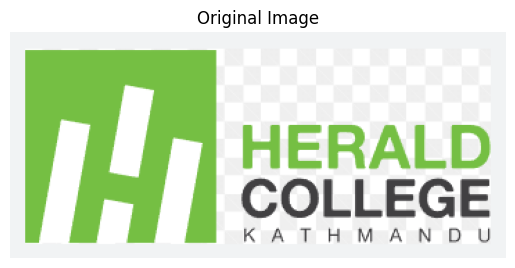

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load the colored image
image_colored = Image.open("/content/Herald.png")
# Display using matplotlib
plt.imshow(image_colored)
plt.title("Original Image")
plt.axis("off")
plt.show()

2. Display only the top left corner of 100x100 pixels.

• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.

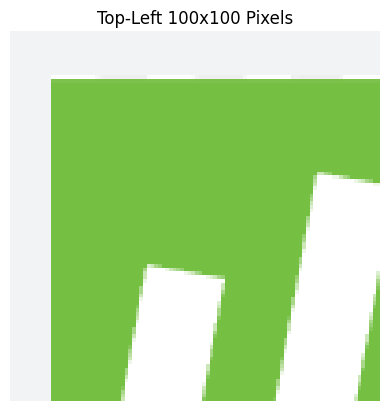

In [3]:
# Convert image to NumPy array
img_array = np.array(image_colored)

# Extract top-left 100x100 region
top_left = img_array[0:100, 0:100]

# Display
plt.imshow(top_left)
plt.title("Top-Left 100x100 Pixels")
plt.axis("off")
plt.show()

3. Show the three color channels (R, G, B).

• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

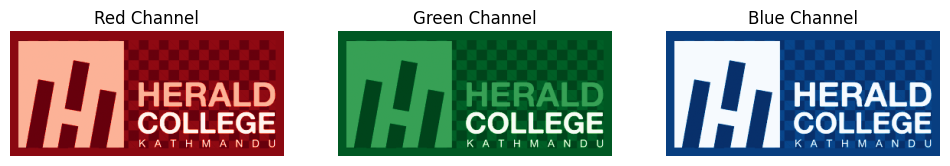

In [4]:
# Separate channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Display each channel
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

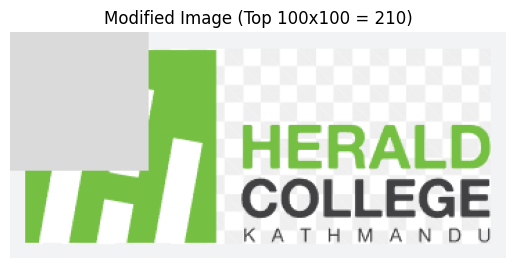

In [5]:
# Create a copy to avoid modifying original
modified_img = img_array.copy()

# Set top-left 100x100 region to 210 (for all channels)
modified_img[0:100, 0:100] = 210

# Display modified image
plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

**2.2 Exercise - 2:**

Complete all the Task.

1. Load and display a grayscale image.

• Load a grayscale image using the Pillow library.

• Display the grayscale image using matplotlib.

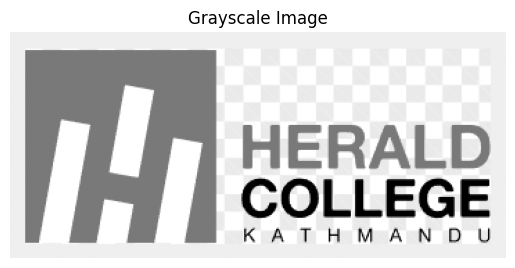

In [6]:
# Load grayscale image
gray_image = Image.open("/content/Herald.png").convert("L")  # "L" mode = grayscale

# Display the grayscale image
plt.imshow(gray_image, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Extract and display the middle section of the image (150 pixels).

• Extract a 150 pixel section from the center of the image using NumPy array slicing.

• Display this cropped image using matplotlib.

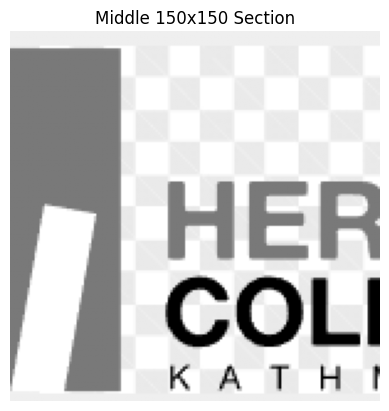

In [7]:
# Convert to NumPy array
gray_array = np.array(gray_image)

# Find image center
height, width = gray_array.shape
center_row = height // 2
center_col = width // 2

# Extract 150x150 center region
half_size = 75  # half of 150
middle_section = gray_array[center_row - half_size : center_row + half_size,
                            center_col - half_size : center_col + half_size]

# Display middle section
plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).

• Display the resulting binary image.

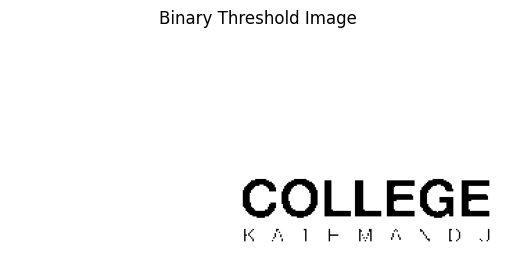

In [8]:
# Apply threshold
binary_image = np.where(gray_array < 100, 0, 255)

# Display binary image
plt.imshow(binary_image, cmap='gray')
plt.title("Binary Threshold Image")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.

• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.

• Display the rotated image using matplotlib.

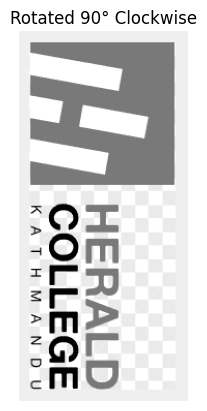

In [9]:
# Using Pillow rotate (counterclockwise, so use -90)
rotated_image = gray_image.rotate(-90, expand=True)

# Display rotated image
plt.imshow(rotated_image, cmap='gray')
plt.title("Rotated 90° Clockwise")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).

• Display the converted RGB image using matplotlib.

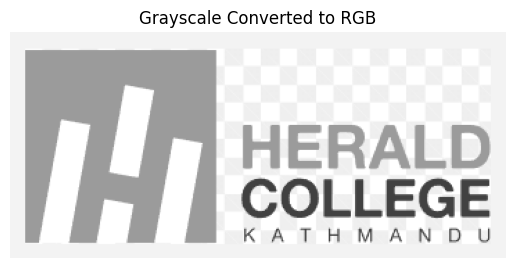

In [10]:
# Convert grayscale to RGB
rgb_image = gray_image.convert("RGB")

# Display RGB image
plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

#3 Image Compression and Decompression using PCA.

In this exercise, build a PCA from scratch using explained variance method for image compression task.
You are expected to compute the necessary matrices from the scratch. Dataset: Use image of your
choice.
**1. Load and Prepare Data:**

• Fetch an image of you choice.{If colour convert to grayscale}

• Center the dataset - Standaridze the Data.

• Calculate the covaraince matrix of the Standaridze data.

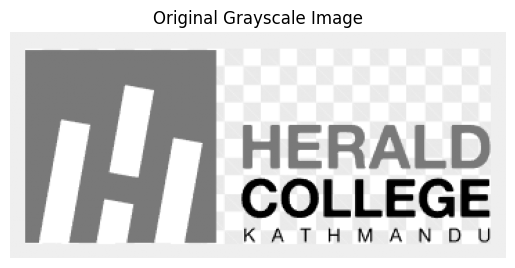

Image shape: (163, 358)


In [13]:
# Load image
image = Image.open("/content/Herald.png")  # replace with your image path

# Convert to grayscale if it's color
gray_image = image.convert("L")

# Convert to NumPy array
img_array = np.array(gray_image)

# Display the grayscale image
plt.imshow(img_array, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

print("Image shape:", img_array.shape)

In [14]:
# Flatten the image into 2D (if necessary)
# Each row = 1 observation (row of image), each column = features (pixels in row)
X = img_array.astype(float)

# Center the data by subtracting the mean
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

print("Data centered. Mean of each column (should be near 0):", np.mean(X_centered, axis=0)[:5])

Data centered. Mean of each column (should be near 0): [0. 0. 0. 0. 0.]


In [15]:
# Covariance matrix
# Note: np.cov expects features in rows by default, so we transpose
cov_matrix = np.cov(X_centered.T)  # shape: (num_pixels, num_pixels)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (358, 358)


**2. Eigen Decomposition and Identifying Principal Components:**

• Compute Eigen Values and Eigen Vectors.

• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.

• Identify the Principal Components with the help of cumulative Sum plot.

In [16]:
# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Number of eigenvalues:", len(eigenvalues))
print("Number of eigenvectors:", eigenvectors.shape)

Number of eigenvalues: 358
Number of eigenvectors: (358, 358)


In [17]:
# Sort eigenvalues and eigenvectors
sorted_index = np.argsort(eigenvalues)[::-1]  # descending order
eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

print("Top 5 eigenvalues:", eigenvalues[:5])

Top 5 eigenvalues: [285057.04440712+0.j 104218.76957882+0.j  79760.23621483+0.j
  70660.10850886+0.j  42164.74369015+0.j]


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


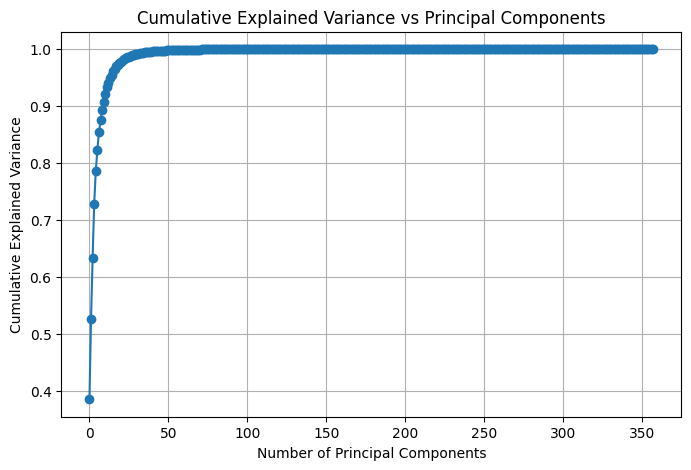

In [18]:
# Explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative variance
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs Principal Components")
plt.grid(True)
plt.show()

In [19]:
k = 50  # choose based on cumulative variance
top_k_eigenvectors = eigenvectors[:, :k]

print("Shape of top k eigenvectors:", top_k_eigenvectors.shape)

Shape of top k eigenvectors: (358, 50)


**3. Reconstruction and Experiment:**

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec-
tors(PCs) to obtain a lower-dimensional representation.

• Experiments: Pick Four different combination of principal components with various ex-
plained variance value and compare the result.

• Display the Results and Evaluate.

In [20]:
# Example: k = 50
k = 50
top_k_eigenvectors = eigenvectors[:, :k]  # shape: (num_features, k)

# Project centered data onto top k eigenvectors
X_compressed = np.dot(X_centered, top_k_eigenvectors)

print("Compressed data shape:", X_compressed.shape)

Compressed data shape: (163, 50)


/tmp/ipykernel_401/4207474313.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(np.uint8)


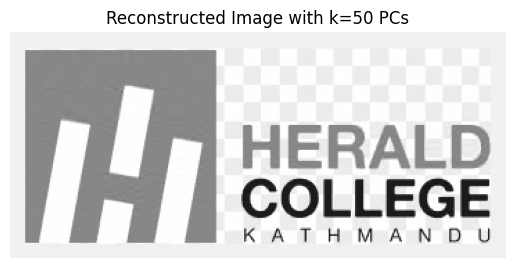

In [21]:
# Reconstruct image
X_reconstructed = np.dot(X_compressed, top_k_eigenvectors.T) + X_mean

# Convert to uint8 for displaying
X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(np.uint8)

# Display reconstructed image
plt.imshow(X_reconstructed, cmap='gray')
plt.title(f"Reconstructed Image with k={k} PCs")
plt.axis("off")
plt.show()

/tmp/ipykernel_401/1659010410.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(np.uint8)


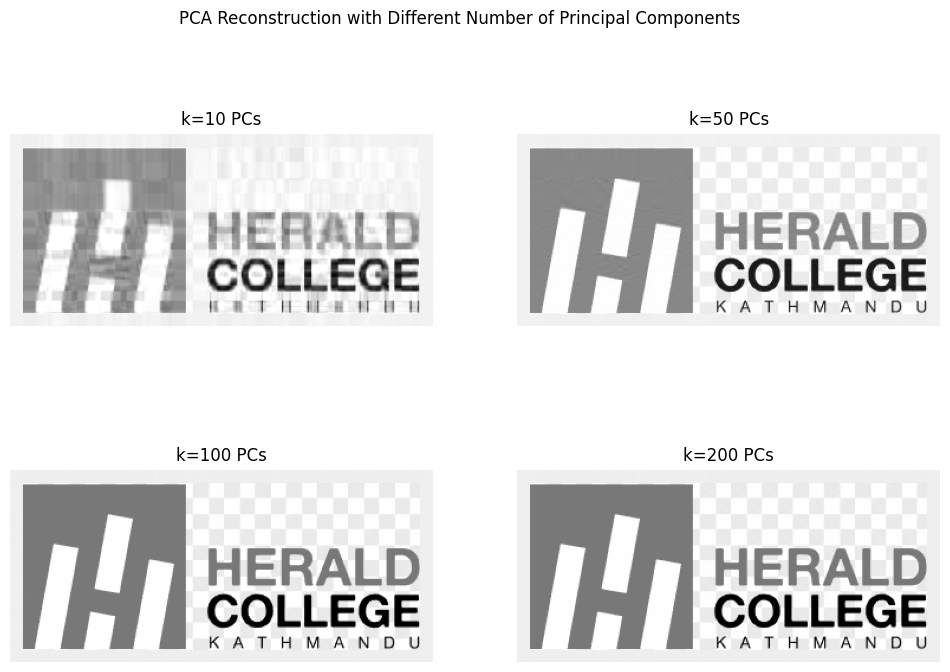

In [22]:
# Four different numbers of principal components
k_values = [10, 50, 100, 200]  # can adjust based on your cumulative variance plot

plt.figure(figsize=(12, 8))

for i, k in enumerate(k_values):
    top_k_eigenvectors = eigenvectors[:, :k]

    # Project and reconstruct
    X_compressed = np.dot(X_centered, top_k_eigenvectors)
    X_reconstructed = np.dot(X_compressed, top_k_eigenvectors.T) + X_mean
    X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(np.uint8)

    # Display each reconstructed image
    plt.subplot(2, 2, i+1)
    plt.imshow(X_reconstructed, cmap='gray')
    plt.title(f"k={k} PCs")
    plt.axis("off")

plt.suptitle("PCA Reconstruction with Different Number of Principal Components")
plt.show()

In [23]:
from sklearn.metrics import mean_squared_error

for k in k_values:
    top_k_eigenvectors = eigenvectors[:, :k]
    X_compressed = np.dot(X_centered, top_k_eigenvectors)
    X_reconstructed = np.dot(X_compressed, top_k_eigenvectors.T) + X_mean
    X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(np.uint8)

    mse = mean_squared_error(img_array, X_reconstructed)
    print(f"k={k} PCs --> MSE = {mse:.2f}")

k=10 PCs --> MSE = 181.04
k=50 PCs --> MSE = 4.54
k=100 PCs --> MSE = 0.50
k=200 PCs --> MSE = 0.46


/tmp/ipykernel_401/1962078354.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(np.uint8)
/tmp/ipykernel_401/1962078354.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(np.uint8)
/tmp/ipykernel_401/1962078354.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(np.uint8)
/tmp/ipykernel_401/1962078354.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(np.uint8)
